In [20]:
import os
from PIL import Image
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

(-0.5, 511.5, 247.5, -0.5)

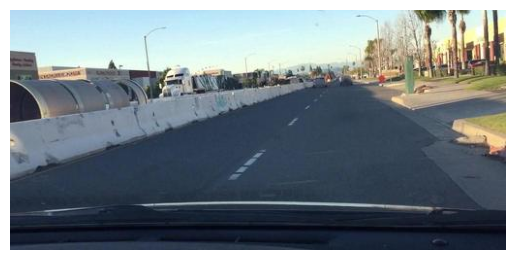

In [21]:
data_dir = "data"

files = sorted(os.listdir(data_dir))

img = Image.open(os.path.join(data_dir, files[0]))
plt.imshow(img)
plt.axis("off")

In [22]:
files[:4]

['Anaheim-0021450d.jpg',
 'Anaheim-00380032.jpg',
 'Anaheim-00752b22.jpg',
 'Anaheim-011a4d5d.jpg']

In [23]:
from collections import Counter

labels = [f.split("-")[0] for f in files]
Counter(labels)

Counter({'SLO': 1588,
         'Anaheim': 1584,
         'Riverside': 1582,
         'San_Diego': 1510,
         'Bakersfield': 1488,
         'Los_Angeles': 1429})

In [24]:
city_to_idx = {
    "Anaheim": 0,
    "Bakersfield": 1,
    "Los_Angeles": 2,
    "Riverside": 3,
    "San_Diego": 4,
    "SLO": 5
}

idx_to_city = {v: k for k, v in city_to_idx.items()}

In [25]:
class SoCalDataset(Dataset):
    
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.files = os.listdir(data_dir)
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        
        filename = self.files[idx]
        img_path = os.path.join(self.data_dir, filename)

        image = Image.open(img_path).convert("RGB")

        label_name = filename.split("-")[0]
        label = city_to_idx[label_name]

        if self.transform:
            image = self.transform(image)

        return image, label

In [32]:
transform = transforms.Compose([
    transforms.ToTensor()
])

dataset = SoCalDataset("data", transform=transform)
image, label = dataset[0]

train_loader = DataLoader(dataset, batch_size=32, shuffle=True)

images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)


torch.Size([32, 3, 248, 512])
torch.Size([32])


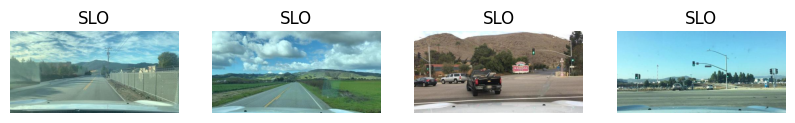

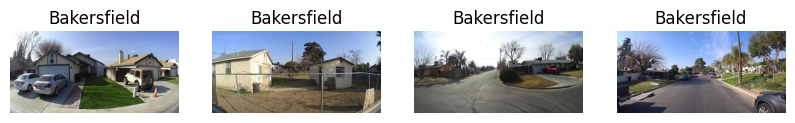

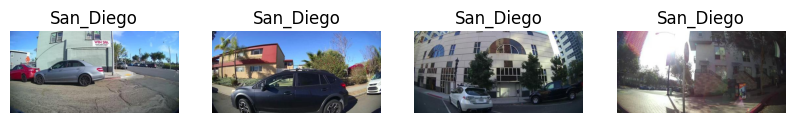

In [33]:
import matplotlib.pyplot as plt

def show_examples(city, n=4):
    imgs = [f for f in files if f.startswith(city)]
    
    plt.figure(figsize=(10,5))
    
    for i in range(n):
        img = Image.open(os.path.join(data_dir, imgs[i]))
        plt.subplot(1,n,i+1)
        plt.imshow(img)
        plt.title(city)
        plt.axis("off")

show_examples("SLO")
show_examples("Bakersfield")
show_examples("San_Diego")